# U-Net H5 Dataset Visualizer
Interactive visualization of paired raw / binary-mask patches from the unified SmartPatches H5.

Reads `/train/raw` + `/train/mask`. When `mask` is absent (the generator was run without `binary_mask_dir`), falls back to deriving binary from `label > 0` on the fly — same contract `H5UNetDataset` enforces at training time.

Patches are stored already whole-volume percentile-normalised (CARE-style), so `raw` should land in roughly `[0, 1]`. If you see big-integer ranges, the H5 was generated with the old code path — regenerate before training.

**Polarity sanity check**: cell foreground is typically a minority class (≤ 50%). If the dataset-wide mask mean comes out > 0.5, the polarity is most likely inverted (mask was True on background, False on cells) — that's what produces negative-foreground logits at inference. The check cell below samples patches and reports the overall fraction.

In [7]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from ipywidgets import IntSlider, Dropdown, VBox, Output, Label
import ipywidgets as widgets
from IPython.display import display, clear_output

In [8]:
# Set the path to your SmartPatches H5 file.
H5_PATH = "/mnt/jean-zay/segmentation_training/xenopus_segmentation.h5"

In [9]:
# Open H5 file and inspect structure
h5f = h5py.File(H5_PATH, 'r')

print("H5 File Structure:")
print(f"Root keys: {list(h5f.keys())}")
for split in h5f.keys():
    print(f"\n{split}/:")
    for key in h5f[split].keys():
        ds = h5f[split][key]
        sample = ds[0]
        print(f"  {key}: {ds.shape}, dtype={ds.dtype}, "
              f"min={sample.min():.4f}, max={sample.max():.4f}")

H5 File Structure:
Root keys: ['train', 'val']

train/:
  label: (35, 16, 256, 256), dtype=int32, min=0.0000, max=308.0000
  mask: (35, 16, 256, 256), dtype=uint8, min=0.0000, max=1.0000
  raw: (35, 16, 256, 256), dtype=float32, min=0.0000, max=1.0000

val/:
  label: (46, 16, 256, 256), dtype=int32, min=0.0000, max=179.0000
  mask: (46, 16, 256, 256), dtype=uint8, min=0.0000, max=1.0000
  raw: (46, 16, 256, 256), dtype=float32, min=0.0000, max=1.0000


## Dataset-wide polarity check
Samples up to `N_SAMPLES_FOR_CHECK` patches per split and plots a dataset-level histogram of raw values + the per-patch foreground-fraction distribution. The verdict line at the bottom tells you whether the mask polarity is canonical or inverted.

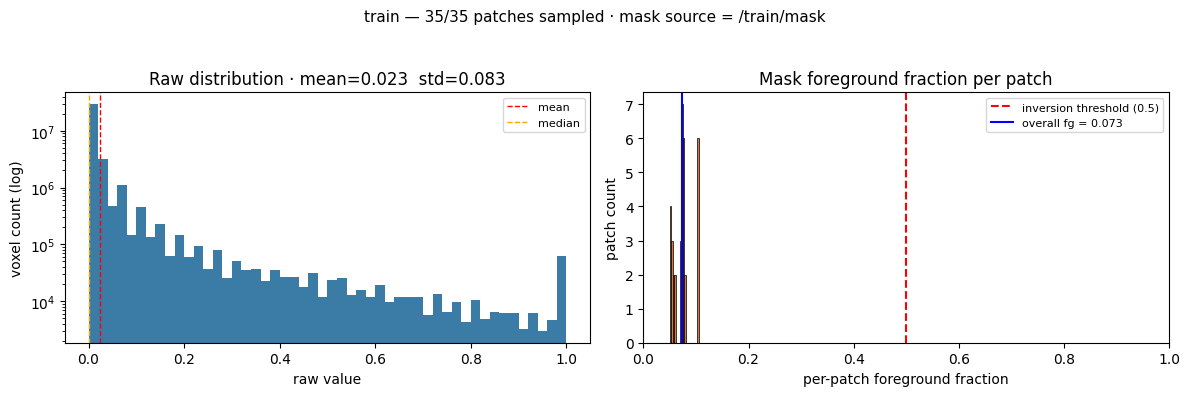

[train] ✓  Polarity looks canonical (< 50% foreground).


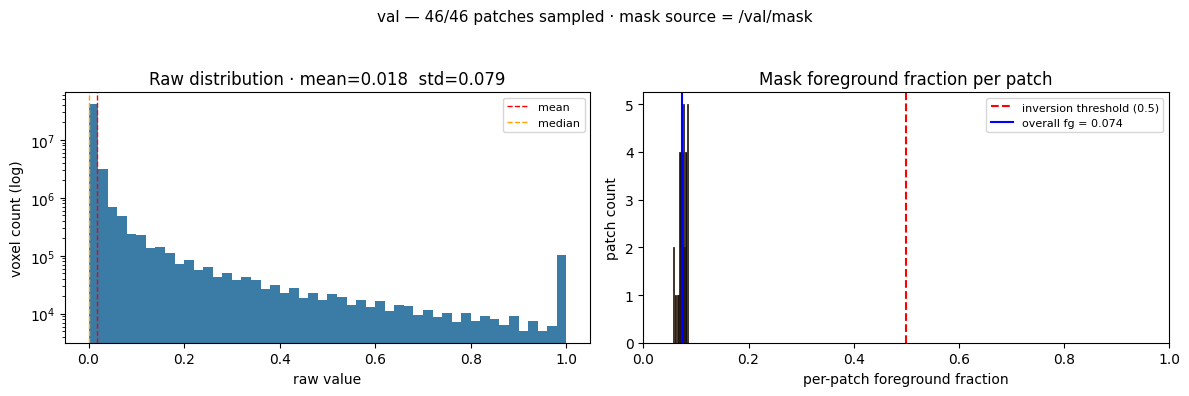

[val] ✓  Polarity looks canonical (< 50% foreground).


In [10]:
N_SAMPLES_FOR_CHECK = 256  # cap, to keep the check fast on big H5s

def _polarity_report(split: str):
    grp = h5f[split]
    raw = grp['raw']
    mask = grp['mask'] if 'mask' in grp else grp.get('label', None)
    mask_source = '/'+split+'/mask' if 'mask' in grp else '/'+split+'/label>0'
    if mask is None:
        print(f"[{split}] no mask or label dataset — skipping")
        return
    n = min(N_SAMPLES_FOR_CHECK, raw.shape[0])
    raw_samples = raw[:n].reshape(n, -1)
    mask_samples = (mask[:n] > 0).astype(np.uint8).reshape(n, -1)

    flat = raw_samples.ravel()
    per_patch_fg = mask_samples.mean(axis=1)
    overall_fg = float(mask_samples.mean())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(
        f"{split} — {n}/{raw.shape[0]} patches sampled · mask source = {mask_source}",
        fontsize=11,
    )
    axes[0].hist(flat, bins=50, color='#3a7ca5', edgecolor='none')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('raw value')
    axes[0].set_ylabel('voxel count (log)')
    axes[0].set_title(
        f"Raw distribution · mean={flat.mean():.3f}  std={flat.std():.3f}"
    )
    axes[0].axvline(flat.mean(), color='red', linestyle='--', linewidth=1, label='mean')
    axes[0].axvline(np.median(flat), color='orange', linestyle='--', linewidth=1, label='median')
    axes[0].legend(loc='upper right', fontsize=8)

    axes[1].hist(per_patch_fg, bins=20, color='#d4773a', edgecolor='black', linewidth=0.5)
    axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='inversion threshold (0.5)')
    axes[1].axvline(overall_fg, color='blue', linestyle='-', linewidth=1.5,
                    label=f'overall fg = {overall_fg:.3f}')
    axes[1].set_xlabel('per-patch foreground fraction')
    axes[1].set_ylabel('patch count')
    axes[1].set_title('Mask foreground fraction per patch')
    axes[1].set_xlim(0, 1)
    axes[1].legend(loc='upper right', fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

    verdict = (
        "⚠️  Polarity likely INVERTED (mask True on background). Regenerate the H5 with flipped mask convention."
        if overall_fg > 0.5 else
        "✓  Polarity looks canonical (< 50% foreground)."
    )
    print(f"[{split}] {verdict}")

for split in h5f.keys():
    _polarity_report(split)

In [ ]:
class UNetH5Visualizer:
    """3D-aware raw / mask viewer for the unified SmartPatches H5.

    Handles both 2D and 3D patches transparently — the Z slider is
    hidden for 2D data. When ``mask`` is absent from the split,
    binary is derived from ``label > 0`` on the fly so the viewer
    shows exactly what ``H5UNetDataset`` will see at training time.
    Bottom row of the figure is a real matplotlib bar chart of the
    binary mask distribution (foreground vs background voxel counts,
    log-y) so polarity and class balance are obvious at a glance.
    """

    def __init__(self, h5_file):
        self.h5f = h5_file
        self.current_split = 'train'
        self._bind_split(self.current_split)

        self.output = Output()
        self.stats_output = Output()

    def _bind_split(self, split):
        grp = self.h5f[split]
        self.raw = grp['raw']
        self.mask = grp['mask'] if 'mask' in grp else None
        self.label = grp['label'] if 'label' in grp else None
        self.n_samples = self.raw.shape[0]
        self.is_3d = self.raw.ndim == 4
        self.n_z = self.raw.shape[1] if self.is_3d else 1

    def switch_split(self, split):
        self.current_split = split
        self._bind_split(split)

    def _get_mask_patch(self, sample_idx):
        if self.mask is not None:
            raw_mask = np.asarray(self.mask[sample_idx])
            return (raw_mask > 0).astype(np.uint8), raw_mask
        if self.label is not None:
            lab = np.asarray(self.label[sample_idx])
            return (lab > 0).astype(np.uint8), lab
        return np.zeros_like(self.raw[sample_idx], dtype=np.uint8), None

    def visualize(self, sample_idx, z_idx, show_overlay):
        with self.output:
            clear_output(wait=True)

            raw_patch = np.asarray(self.raw[sample_idx])
            mask_patch, mask_raw_patch = self._get_mask_patch(sample_idx)

            if self.is_3d:
                raw_slice = raw_patch[z_idx]
                mask_slice = mask_patch[z_idx]
                z_label = f", Z={z_idx}"
            else:
                raw_slice = raw_patch
                mask_slice = mask_patch
                z_label = ""

            ncols = 3 if show_overlay else 2
            fig = plt.figure(figsize=(5 * ncols, 9))
            gs = GridSpec(
                nrows=2, ncols=ncols, figure=fig,
                height_ratios=[1.2, 1], hspace=0.35,
            )

            ax_raw = fig.add_subplot(gs[0, 0])
            ax_raw.imshow(raw_slice, cmap='gray')
            ax_raw.set_title(f'Raw — Sample {sample_idx}{z_label}')
            ax_raw.axis('off')

            ax_mask = fig.add_subplot(gs[0, 1])
            ax_mask.imshow(mask_slice, cmap='Reds', vmin=0, vmax=1)
            mask_src = 'mask' if self.mask is not None else 'label>0'
            fg_frac_slice = float(mask_slice.mean()) * 100
            ax_mask.set_title(f'Binary ({mask_src}) — slice fg {fg_frac_slice:.1f}%')
            ax_mask.axis('off')

            if show_overlay:
                ax_ovr = fig.add_subplot(gs[0, 2])
                ax_ovr.imshow(raw_slice, cmap='gray')
                mask_rgba = np.zeros(mask_slice.shape + (4,), dtype=np.float32)
                mask_rgba[..., 0] = 1.0
                mask_rgba[..., 3] = np.where(mask_slice > 0, 0.4, 0.0)
                ax_ovr.imshow(mask_rgba)
                ax_ovr.set_title('Overlay (raw + mask)')
                ax_ovr.axis('off')

            # Bar chart of the binary-mask value distribution across
            # the whole patch — foreground vs background voxel counts.
            # Log-y because foreground is the minority class and a
            # linear bar would render it as a sliver.
            ax_hist = fig.add_subplot(gs[1, :])
            uniq, cnts = np.unique(mask_patch, return_counts=True)
            value_to_count = dict(zip(uniq.tolist(), cnts.tolist()))
            bg_n = int(value_to_count.get(0, 0))
            fg_n = int(value_to_count.get(1, 0))
            other = int(mask_patch.size - bg_n - fg_n)
            xs, ys, colors, labels = [], [], [], []
            if bg_n:
                xs.append('0 (background)')
                ys.append(bg_n)
                colors.append('#5a6a7a')
                labels.append(f'{bg_n}\n{bg_n/mask_patch.size*100:.2f}%')
            if fg_n:
                xs.append('1 (foreground)')
                ys.append(fg_n)
                colors.append('#d4773a')
                labels.append(f'{fg_n}\n{fg_n/mask_patch.size*100:.2f}%')
            if other:
                xs.append(f'other ({other} voxels)')
                ys.append(other)
                colors.append('#b03a3a')
                labels.append(f'{other}\n{other/mask_patch.size*100:.2f}%')
            bars = ax_hist.bar(xs, ys, color=colors, edgecolor='black', linewidth=0.5)
            ax_hist.set_yscale('log')
            ax_hist.set_ylabel('voxel count (log)')
            ax_hist.set_title(
                f"Binary mask distribution — fg/total = {fg_n}/{mask_patch.size} "
                f"({fg_n/mask_patch.size*100:.2f}%)"
            )
            for bar, label in zip(bars, labels):
                ax_hist.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    label,
                    ha='center', va='bottom', fontsize=10,
                )

            plt.show()

        with self.stats_output:
            clear_output(wait=True)
            print("=" * 70)
            print(f"Patch {sample_idx} — {self.current_split} split")
            print("=" * 70)

            print(f"Raw  shape={raw_patch.shape}  dtype={raw_patch.dtype}")
            print(f"Mask shape={mask_patch.shape}  dtype={mask_patch.dtype}  "
                  f"source: {'/'+self.current_split+'/mask' if self.mask is not None else 'derived from label>0'}")
            uniq, cnts = np.unique(mask_patch, return_counts=True)
            print(f"Binary unique values: {dict(zip(uniq.tolist(), cnts.tolist()))}")
            if mask_raw_patch is not None:
                ruq, rcnts = np.unique(mask_raw_patch, return_counts=True)
                if len(ruq) <= 20:
                    print(f"Raw mask unique values: {dict(zip(ruq.tolist(), rcnts.tolist()))}")
                else:
                    print(f"Raw mask unique values: {len(ruq)} distinct "
                          f"(min={ruq.min()}, max={ruq.max()})")
            fg = int(mask_patch.sum())
            total = mask_patch.size
            print(f"Foreground voxels (whole patch): {fg}/{total}  ({fg/total*100:.2f}%)")
            print("=" * 70)

    def create_widgets(self):
        split_dropdown = Dropdown(
            options=list(self.h5f.keys()),
            value=self.current_split,
            description='Split:'
        )

        sample_slider = IntSlider(
            min=0, max=self.n_samples - 1, step=1, value=0,
            description='Sample:', continuous_update=False
        )

        z_slider = IntSlider(
            min=0, max=max(self.n_z - 1, 0), step=1, value=self.n_z // 2,
            description='Z slice:', continuous_update=False
        )
        if not self.is_3d:
            z_slider.layout.display = 'none'

        overlay_checkbox = widgets.Checkbox(value=True, description='Show Overlay')

        def on_split_change(change):
            self.switch_split(change['new'])
            sample_slider.max = self.n_samples - 1
            sample_slider.value = min(sample_slider.value, self.n_samples - 1)
            z_slider.max = max(self.n_z - 1, 0)
            z_slider.value = min(z_slider.value, max(self.n_z - 1, 0))
            z_slider.layout.display = 'flex' if self.is_3d else 'none'
            self.visualize(sample_slider.value, z_slider.value, overlay_checkbox.value)

        split_dropdown.observe(on_split_change, names='value')

        def update(sample_idx, z_idx, show_overlay):
            self.visualize(sample_idx, z_idx, show_overlay)

        widgets.interactive(
            update,
            sample_idx=sample_slider,
            z_idx=z_slider,
            show_overlay=overlay_checkbox,
        )

        controls = VBox([
            Label(f'Dataset: {self.n_samples} patches, shape: {self.raw.shape}'),
            split_dropdown,
            sample_slider,
            z_slider,
            overlay_checkbox,
        ])

        display(controls)
        display(self.output)
        display(self.stats_output)

        self.visualize(0, self.n_z // 2, True)

In [ ]:
viz = UNetH5Visualizer(h5f)
viz.create_widgets()

Output()

Output()